Bu derste amaç, daha önce kavramsal olarak incelediğimiz üç klasik problemi Mealpy kullanarak çözmektir:


- Gezgin Satıcı Problemi (TSP),

- Sırt Çantası Problemi (Knapsack),
- Çizelgeleme Problemi

Bu uygulamalarda problemleri kodla tanımlayacağız Mealpy ile farklı algoritmalar deneyeceğiz, en iyi çözümü yorumlayacağız, yakınsama eğrilerini karşılaştıracağız.

# Install Colab

In [1]:
!pip install mealpy

# Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mealpy import FloatVar, BinaryVar, PermutationVar
from mealpy import GA, GWO, PSO

# Necessary Function

In [3]:
def plot_histories(histories, title="Yakınsama Eğrisi"):
    plt.figure(figsize=(8, 5))
    for name, hist in histories.items():
        plt.plot(hist, label=name)
    plt.xlabel("İterasyon")
    plt.ylabel("En iyi fitness")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def run_optimizers(problem_dict, optimizers):
    results = []
    histories = {}

    for name, model in optimizers.items():
        g_best = model.solve(problem_dict)
        best_fit = g_best.target.fitness
        best_sol = g_best.solution

        results.append({
            "Algoritma": name,
            "En İyi Fitness": best_fit
        })
        histories[name] = model.history.list_global_best_fit

        print(f"\n{name}")
        print("-" * len(name))
        print("Best fitness:", best_fit)
        print("Best solution:", best_sol)

    df = pd.DataFrame(results).sort_values("En İyi Fitness").reset_index(drop=True)
    return df, histories

# Problem 1: Gezgin Satıcı Problemi (TSP)

## Problem tanımı

Bir teknik servis ekibi 12 farklı hastaneyi dolaşacak ve başladığı merkeze geri dönecektir. Amaç, toplam rota uzunluğunu minimize etmektir.

- **Karar değişkeni:** şehir sırası, yani bir permütasyon

- **Amaç fonksiyonu:** toplam turun uzunluğu

## Veri oluşturma

In [4]:
np.random.seed(42)

n_cities = 12
city_names = [f"H{i}" for i in range(n_cities)]

# 2B koordinatlar
coords = np.random.uniform(0, 100, size=(n_cities, 2))

# Mesafe matrisi
dist_matrix = np.zeros((n_cities, n_cities))
for i in range(n_cities):
    for j in range(n_cities):
        dist_matrix[i, j] = np.linalg.norm(coords[i] - coords[j])

coord_df = pd.DataFrame(coords, columns=["x", "y"], index=city_names)
coord_df

,x,y
H0,37.454012,95.071431
H1,73.199394,59.865848
H2,15.601864,15.599452
H3,5.808361,86.617615
H4,60.111501,70.807258
H5,2.058449,96.990985
H6,83.244264,21.233911
H7,18.182497,18.340451
H8,30.424224,52.475643
H9,43.194502,29.122914


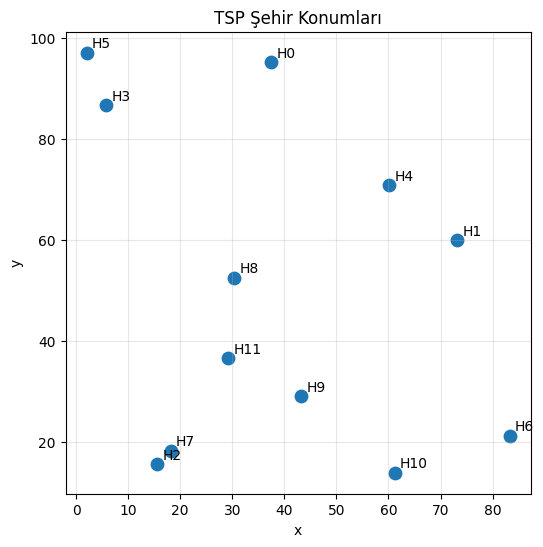

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(coords[:, 0], coords[:, 1], s=80)

for i, name in enumerate(city_names):
    plt.text(coords[i, 0] + 1, coords[i, 1] + 1, name)

plt.title("TSP Şehir Konumları")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

## Amaç fonksiyonu

In [6]:
def tsp_objective(solution):
    route = np.array(solution, dtype=int)
    total_distance = 0.0

    for i in range(len(route) - 1):
        total_distance += dist_matrix[route[i], route[i + 1]]

    # Başlangıca dönüş
    total_distance += dist_matrix[route[-1], route[0]]
    return total_distance

## Mealpy problem tanımı

Permutation tabanlı problem olduğu için **PermutationVar** kullanıyoruz. Mealpy’nin güncel dokümantasyonunda permütasyon tabanlı kombinatoryal problemler için bu değişken sınıfı öneriliyor.

In [7]:
tsp_problem = {
    "bounds": PermutationVar(valid_set=tuple(range(n_cities)), name="route"),
    "obj_func": tsp_objective,
    "minmax": "min",
    "save_population": False,
}

## Farklı algoritmalarla çözüm

In [8]:
tsp_optimizers = {
    "GA": GA.OriginalGA(epoch=300, pop_size=60),
    "PSO": PSO.OriginalPSO(epoch=300, pop_size=60),
    "GWO": GWO.OriginalGWO(epoch=300, pop_size=60)
}

In [9]:
tsp_results, tsp_histories = run_optimizers(tsp_problem, tsp_optimizers)
tsp_results

INFO:mealpy.evolutionary_based.GA.OriginalGA:OriginalGA(epoch=300, pop_size=60, pc=0.95, pm=0.025, selection=tournament, crossover=uniform, mutation=flip, k_way=0.2, mutation_multipoints=True)
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 1, Current best: 482.38428486947487, Global best: 482.38428486947487, Runtime: 0.00010 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 2, Current best: 482.38428486947487, Global best: 482.38428486947487, Runtime: 0.00017 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 3, Current best: 482.38428486947487, Global best: 482.38428486947487, Runtime: 0.00013 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 4, Current best: 482.38428486947487, Global best: 482.38428486947487, Runtime: 0.00012 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 5, Current best: 482.38428486947487, Global best: 482.38428486947487, Runtime: 0.00016 secon


GA
--
Best fitness: 482.38428486947487
Best solution: [ 6.  1. 11.  2. 10.  4.  3.  5.  0.  8.  9.  7.]


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 14, Current best: 445.65173207701577, Global best: 445.65173207701577, Runtime: 0.01469 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 15, Current best: 443.1858586043465, Global best: 443.1858586043465, Runtime: 0.01056 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 16, Current best: 443.1858586043465, Global best: 443.1858586043465, Runtime: 0.00943 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 17, Current best: 443.1858586043465, Global best: 443.1858586043465, Runtime: 0.01264 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 18, Current best: 443.1858586043465, Global best: 443.1858586043465, Runtime: 0.01509 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 19, Current best: 443.1858586043465, Global best: 443.1858586043465, Runtime: 0.01375 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 


PSO
---
Best fitness: 386.7350960940922
Best solution: [ 3  0  4  1  6 10  7  8  9 11  2  5]


INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 9, Current best: 410.2720419407955, Global best: 410.2720419407955, Runtime: 0.02578 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 10, Current best: 410.2720419407955, Global best: 410.2720419407955, Runtime: 0.01414 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 11, Current best: 410.2720419407955, Global best: 410.2720419407955, Runtime: 0.02255 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 12, Current best: 410.2720419407955, Global best: 410.2720419407955, Runtime: 0.02301 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 13, Current best: 410.2720419407955, Global best: 410.2720419407955, Runtime: 0.02445 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 14, Current best: 410.2720419407955, Global best: 410.2720419407955, Runtime: 0.01287 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 15,


GWO
---
Best fitness: 366.12345679105675
Best solution: [ 5  0  3  4  1  6 10  2  7  9 11  8]


,Algoritma,En İyi Fitness
0,GWO,366.123457
1,PSO,386.735096
2,GA,482.384285


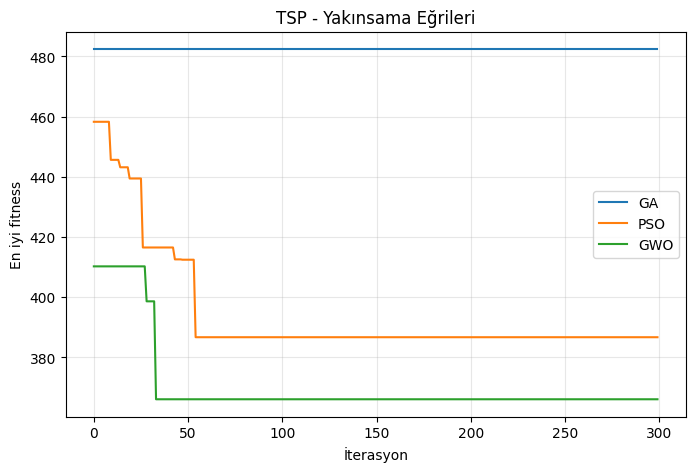

In [10]:
plot_histories(tsp_histories, title="TSP - Yakınsama Eğrileri")

## En iyi rotayı çizdirme

In [11]:
best_model_name = tsp_results.iloc[0]["Algoritma"]
best_model = tsp_optimizers[best_model_name]
best_route = np.array(best_model.g_best.solution, dtype=int)

print("En iyi algoritma:", best_model_name)
print("En iyi rota indeksleri:", best_route)
print("En iyi rota isimleri:", [city_names[i] for i in best_route])
print("Toplam mesafe:", best_model.g_best.target.fitness)

En iyi algoritma: GWO
En iyi rota indeksleri: [ 5  0  3  4  1  6 10  2  7  9 11  8]
En iyi rota isimleri: ['H5', 'H0', 'H3', 'H4', 'H1', 'H6', 'H10', 'H2', 'H7', 'H9', 'H11', 'H8']
Toplam mesafe: 366.12345679105675


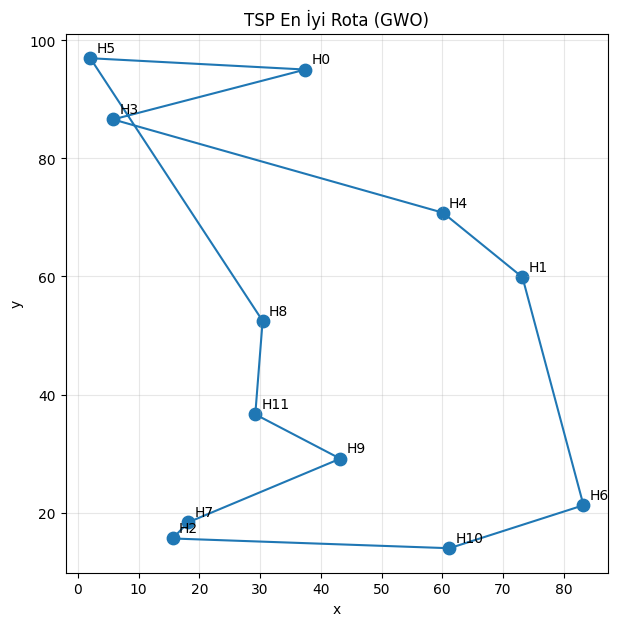

In [12]:
route_coords = coords[best_route]
route_coords_closed = np.vstack([route_coords, route_coords[0]])

plt.figure(figsize=(7, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=80)

for i, name in enumerate(city_names):
    plt.text(coords[i, 0] + 1, coords[i, 1] + 1, name)

plt.plot(route_coords_closed[:, 0], route_coords_closed[:, 1], marker="o")
plt.title(f"TSP En İyi Rota ({best_model_name})")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

# Problem 2: Sırt Çantası Problemi (Knapsack)

## Problem tanımı

Bir acil sağlık drone’u 20 farklı tıbbi malzeme arasından seçim yapacaktır.

Her malzemenin ağırlığı ve önemi/değeri vardır.

- **Amaç:** kapasiteyi aşmadan toplam değeri maksimize etmek
- **Karar değişkeni:** her malzeme seçildi mi seçilmedi mi, yani binary yapı

## Veri oluşturma

In [13]:
np.random.seed(123)

n_items = 20
weights = np.random.randint(2, 15, size=n_items)
values = np.random.randint(10, 100, size=n_items)

capacity = int(weights.sum() * 0.35)

items_df = pd.DataFrame({
    "Malzeme": [f"M{i+1}" for i in range(n_items)],
    "Ağırlık": weights,
    "Değer": values
})

print("Kapasite:", capacity)
items_df

Kapasite: 45


,Malzeme,Ağırlık,Değer
0,M1,4,90
1,M2,14,78
2,M3,4,59
3,M4,8,65
4,M5,3,77
5,M6,5,12
6,M7,12,94
7,M8,13,49
8,M9,11,76
9,M10,8,94


## Amaç fonksiyonu

In [14]:
def knapsack_objective(solution):
    x = np.array(solution, dtype=int)

    total_weight = np.sum(weights * x)
    total_value = np.sum(values * x)

    penalty = 0.0
    if total_weight > capacity:
        penalty = 1000 * (total_weight - capacity)

    # Maksimizasyonu minimizasyona çevirmek için eksi
    return -total_value + penalty

## Mealpy Problem tanımı

In [15]:
knapsack_problem = {
    "bounds": BinaryVar(n_vars=n_items, name="pick"),
    "obj_func": knapsack_objective,
    "minmax": "min",
    "log_to": None,
    "save_population": False,
}

## Farklı algoritmalarla çözüm

In [16]:
knapsack_optimizers = {
    "GA": GA.OriginalGA(epoch=300, pop_size=60),
    "PSO": PSO.OriginalPSO(epoch=300, pop_size=60),
    "GWO": GWO.OriginalGWO(epoch=300, pop_size=60)
}

In [17]:
knapsack_results, knapsack_histories = run_optimizers(knapsack_problem, knapsack_optimizers)
knapsack_results


GA
--
Best fitness: -486.0
Best solution: [0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1.]

PSO
---
Best fitness: -807.0
Best solution: [1.19879265 0.80864451 1.08340234 0.70775912 1.59447382 0.53840342
 1.54966899 0.89541223 0.8437908  1.28611252 1.23491431 1.56325451
 1.0387876  0.17921891 1.7281885  1.82233847 0.85655467 0.66505771
 0.40024269 1.17405138]

GWO
---
Best fitness: -781.0
Best solution: [1.70907893 0.         1.9999     0.24835646 1.47354324 0.757387
 0.00874345 0.75730096 0.         1.54212387 1.9999     1.99020607
 1.9999     0.01528034 0.09815625 1.45862034 0.36957905 1.07499571
 1.62615779 1.94687021]


,Algoritma,En İyi Fitness
0,PSO,-807.0
1,GWO,-781.0
2,GA,-486.0


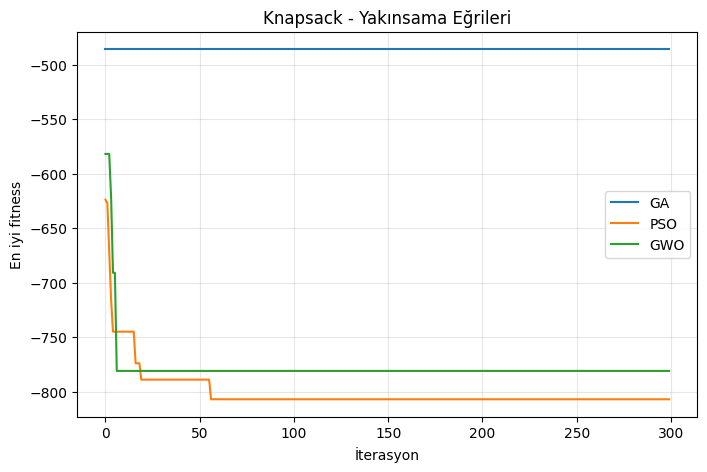

In [30]:
plot_histories(knapsack_histories, title="Knapsack - Yakınsama Eğrileri")

Knapsack çözümünün mantıksal temsili 0 ve 1’lerden oluşmalı!

* GA → binary probleme doğal daha yakın

* PSO / GWO → continuous algoritmalar

* Knapsack gibi ayrık problemlerde ek bir eşikleme / yuvarlama / binary mapping gerekir.


PSO ve GWO çıktılarının continuous gelmesinin nedeni, bu algoritmaların özünde sürekli uzayda çalışan optimizasyon yöntemleri olmasıdır.

Bu tarz durumlarda çözümü yorumlamadan önce binary’ye dönüşüm işlemi gerçekleştiririz.



```
best_x_raw = best_model.g_best.solution
best_x = (np.array(best_x_raw) > 0.5).astype(int)
```



## En iyi çözümü yorumlama

In [29]:
best_model_name = knapsack_results.iloc[0]["Algoritma"]
best_model = knapsack_optimizers[best_model_name]

best_x_raw = np.array(best_model.g_best.solution)

# Continuous çıktıyı binary'ye dönüştür
best_x = np.floor(best_x_raw).astype(int)
best_x = np.clip(best_x, 0, 1)

selected_items = items_df.copy()
selected_items["Seçildi"] = best_x
selected_items = selected_items[selected_items["Seçildi"] == 1].reset_index(drop=True)

total_weight = np.sum(weights * best_x)
total_value = np.sum(values * best_x)

print("En iyi algoritma:", best_model_name)
print("Ham çözüm:", best_x_raw)
print("Binary çözüm:", best_x)
print("Toplam ağırlık:", total_weight)
print("Toplam değer:", total_value)
print("Kapasite:", capacity)

selected_items

En iyi algoritma: PSO
Ham çözüm: [1.19879265 0.80864451 1.08340234 0.70775912 1.59447382 0.53840342
 1.54966899 0.89541223 0.8437908  1.28611252 1.23491431 1.56325451
 1.0387876  0.17921891 1.7281885  1.82233847 0.85655467 0.66505771
 0.40024269 1.17405138]
Binary çözüm: [1 0 1 0 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 1]
Toplam ağırlık: 45
Toplam değer: 807
Kapasite: 45


,Malzeme,Ağırlık,Değer,Seçildi
0,M1,4,90,1
1,M3,4,59,1
2,M5,3,77,1
3,M7,12,94,1
4,M10,8,94,1
5,M11,3,57,1
6,M12,2,71,1
7,M13,3,58,1
8,M15,2,62,1
9,M16,2,95,1


# Problem 3: Çizelgeleme

## Problem tanımı

Bir hastanede 10 ameliyat/iş tek ameliyathanede yapılacaktır. Her işin süresi farklıdır.

**Amaç:** toplam tamamlanma sürelerini minimize etmek

Bu, önceki haftalarda anlattığınız kümülatif toplam mantığının daha büyük boyutlu bir versiyonudur.

**Karar değişkeni:** iş sırası, yani permütasyon

## Veri oluşturma

In [21]:
np.random.seed(7)

n_jobs = 10
job_names = [f"J{i+1}" for i in range(n_jobs)]
processing_times = np.random.randint(1, 12, size=n_jobs)

jobs_df = pd.DataFrame({
    "İş": job_names,
    "Süre": processing_times
})

jobs_df

,İş,Süre
0,J1,5
1,J2,10
2,J3,7
3,J4,4
4,J5,4
5,J6,8
6,J7,8
7,J8,10
8,J9,8
9,J10,9


## Amaç fonksiyonu

In [22]:
def scheduling_objective(solution):
    order = np.array(solution, dtype=int)

    cumulative_time = 0
    total_completion_time = 0

    for job_idx in order:
        cumulative_time += processing_times[job_idx]
        total_completion_time += cumulative_time

    return total_completion_time

## Melapy Problem tanımı

In [23]:
scheduling_problem = {
    "bounds": PermutationVar(valid_set=tuple(range(n_jobs)), name="order"),
    "obj_func": scheduling_objective,
    "minmax": "min",
    "save_population": False,
}

## Farklı algoritmalarla çözüm

In [24]:
scheduling_optimizers = {
    "GA": GA.OriginalGA(epoch=300, pop_size=60),
    "PSO": PSO.OriginalPSO(epoch=300, pop_size=60),
    "GWO": GWO.OriginalGWO(epoch=300, pop_size=60)
}

In [25]:
scheduling_results, scheduling_histories = run_optimizers(scheduling_problem, scheduling_optimizers)
scheduling_results

INFO:mealpy.evolutionary_based.GA.OriginalGA:OriginalGA(epoch=300, pop_size=60, pc=0.95, pm=0.025, selection=tournament, crossover=uniform, mutation=flip, k_way=0.2, mutation_multipoints=True)
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 1, Current best: 362.0, Global best: 362.0, Runtime: 0.00006 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 2, Current best: 362.0, Global best: 362.0, Runtime: 0.00022 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 3, Current best: 362.0, Global best: 362.0, Runtime: 0.00016 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 4, Current best: 362.0, Global best: 362.0, Runtime: 0.00013 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 5, Current best: 362.0, Global best: 362.0, Runtime: 0.00015 seconds
INFO:mealpy.evolutionary_based.GA.OriginalGA:>>>Problem: P, Epoch: 6, Current best: 362.0, Global best: 362.0, Runtime: 0.00013


GA
--
Best fitness: 362.0
Best solution: [0. 3. 6. 4. 7. 9. 5. 2. 8. 1.]


INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 16, Current best: 354.0, Global best: 354.0, Runtime: 0.01112 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 17, Current best: 353.0, Global best: 353.0, Runtime: 0.01239 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 18, Current best: 353.0, Global best: 353.0, Runtime: 0.01442 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 19, Current best: 353.0, Global best: 353.0, Runtime: 0.01284 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 20, Current best: 353.0, Global best: 353.0, Runtime: 0.01184 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 21, Current best: 353.0, Global best: 353.0, Runtime: 0.01038 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 22, Current best: 353.0, Global best: 353.0, Runtime: 0.01141 seconds
INFO:mealpy.swarm_based.PSO.OriginalPSO:>>>Problem: P, Epoch: 23, Current be


PSO
---
Best fitness: 348.0
Best solution: [3 4 0 2 8 9 1 6 5 7]


INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 18, Current best: 347.0, Global best: 347.0, Runtime: 0.00887 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 19, Current best: 347.0, Global best: 347.0, Runtime: 0.01157 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 20, Current best: 347.0, Global best: 347.0, Runtime: 0.01100 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 21, Current best: 347.0, Global best: 347.0, Runtime: 0.01481 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 22, Current best: 347.0, Global best: 347.0, Runtime: 0.01367 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 23, Current best: 347.0, Global best: 347.0, Runtime: 0.01369 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 24, Current best: 347.0, Global best: 347.0, Runtime: 0.01233 seconds
INFO:mealpy.swarm_based.GWO.OriginalGWO:>>>Problem: P, Epoch: 25, Current be


GWO
---
Best fitness: 346.0
Best solution: [3 4 2 0 5 8 6 1 7 9]


,Algoritma,En İyi Fitness
0,GWO,346.0
1,PSO,348.0
2,GA,362.0


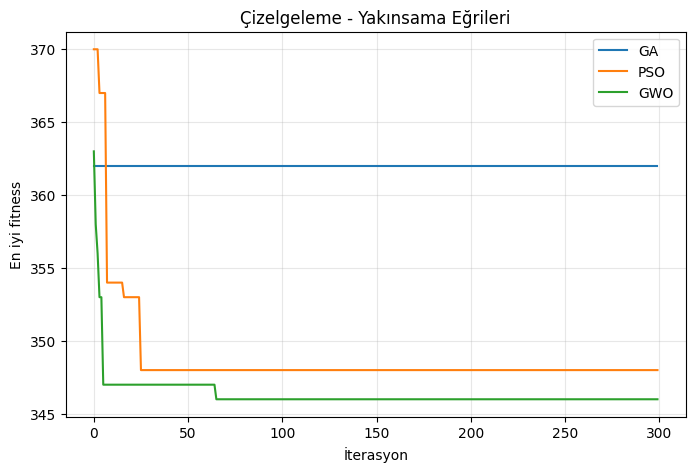

In [26]:
plot_histories(scheduling_histories, title="Çizelgeleme - Yakınsama Eğrileri")

## En iyi sırayı yorumlama

In [27]:
best_model_name = scheduling_results.iloc[0]["Algoritma"]
best_model = scheduling_optimizers[best_model_name]
best_order = np.array(best_model.g_best.solution, dtype=int)

ordered_jobs = jobs_df.iloc[best_order].copy().reset_index(drop=True)

completion_times = []
cum = 0
for t in ordered_jobs["Süre"]:
    cum += t
    completion_times.append(cum)

ordered_jobs["Tamamlanma Süresi"] = completion_times

print("En iyi algoritma:", best_model_name)
print("Toplam tamamlanma süresi:", best_model.g_best.target.fitness)

ordered_jobs

En iyi algoritma: GWO
Toplam tamamlanma süresi: 346.0


,İş,Süre,Tamamlanma Süresi
0,J4,4,4
1,J5,4,8
2,J3,7,15
3,J1,5,20
4,J6,8,28
5,J9,8,36
6,J7,8,44
7,J2,10,54
8,J8,10,64
9,J10,9,73


# Tek hücrede özet karşılaştırma

In [28]:
summary_df = pd.DataFrame([
    {
        "Problem": "TSP",
        "En İyi Algoritma": tsp_results.iloc[0]["Algoritma"],
        "En İyi Fitness": tsp_results.iloc[0]["En İyi Fitness"]
    },
    {
        "Problem": "Knapsack",
        "En İyi Algoritma": knapsack_results.iloc[0]["Algoritma"],
        "En İyi Fitness": knapsack_results.iloc[0]["En İyi Fitness"]
    },
    {
        "Problem": "Çizelgeleme",
        "En İyi Algoritma": scheduling_results.iloc[0]["Algoritma"],
        "En İyi Fitness": scheduling_results.iloc[0]["En İyi Fitness"]
    }
])

summary_df

,Problem,En İyi Algoritma,En İyi Fitness
0,TSP,GWO,366.123457
1,Knapsack,PSO,-807.000000
2,Çizelgeleme,GWO,346.000000


Bu uygulamalarda gördüğümüz gibi:

Problem tanımı değiştikçe karar değişkeni tipi de değişmektedir.

- TSP ve çizelgeleme permütasyon tabanlıdır.
- Knapsack binary seçim problemidir.

Mealpy, uygun değişken türü tanımlandığında bu farklı problem yapılarını aynı çerçevede çözmeye imkân verir.

Algoritmaların ortak mantığı: aday çözüm üretmek, fitness hesaplamak ve çözümleri iteratif olarak iyileştirmektir. history nesnesi üzerinden yakınsama ve performans takibi yapılabilir

# ÖDEV

- Ödev 1'de Biyomedikal alanda tasarladığınız klasik optimizasyon problemini problemin boyutunu (En az 10 boyutlu olacak şekilde) genişletiniz. Colab üzerinde problemi, karar değişkenlerini, amaç fonksiyonunu tanımlayınız.

- Veriler oluşturulurken random değerler yerine gerçek veriler kullanınız. Örneğin TSP için Google Maps'ten koordinatlar çekilebilir. Cihaz satın alma, ameliyathane vs için Google üzerinden küçük bir araştırma yapınız.

- Tasarladığınız problemi yukarıdaki optimizasyon algoritmaları (Ödev 2'de sorumlu olduğunuz **Optimizasyon Algoritmasını** da ekleyiniz.) ile çözünüz. Sonuçları karşılaştırınız.